## Create the element object encoding the IVU Geometric Impedance

### Imports

In [2]:
import os
import sys
import importlib
import warnings

import numpy as _np

import pycolleff.impedances as imp
import pycolleff.process_wakes as ems

warnings.filterwarnings("ignore")

utils = importlib.import_module('utils')

### Define paths to simulation files

In [ ]:
# Start with long. results
folder_gap4 = [
        '', 'home', 'henrique.silvestre', 'data', 'em_simulations', 'ivu_flexible_taper',
        'taper_gap4_width50_length100_radius50','echo3d', 'll',
        'ss400_bl2000', 'analysis', 'SimulData.pickle']

folder_gap14 = folder_gap4.copy()
folder_gap14[-6] = 'taper_gap14_width50_length100_radius50'

folder_gap24 = folder_gap4.copy()
folder_gap24[-6] = 'taper_gap24_width50_length100_radius50'

folder_gaps = [folder_gap4, folder_gap14, folder_gap24]
wakedirs = [os.path.sep.join(folder_gap) for folder_gap in folder_gaps]
print(wakedirs[0])

dataLs = [ems.load_processed_data(wakedir) for wakedir in wakedirs]

# Plane y
for folder_gap in folder_gaps:
    folder_gap[-4] = 'dy'
wakedirs = [os.path.sep.join(folder_gap) for folder_gap in folder_gaps]
print(wakedirs[0])

dataYs = [ems.load_processed_data(wakedir) for wakedir in wakedirs]

# Plane x
for folder_gap in folder_gaps:
    folder_gap[-4] = 'dx'
wakedirs = [os.path.sep.join(folder_gap) for folder_gap in folder_gaps]
print(wakedirs[0])

dataXs = [ems.load_processed_data(wakedir) for wakedir in wakedirs]

/home/henrique.silvestre/data/em_simulations/ivu_flexible_taper/taper_gap4_width50_length100_radius50/echo3d/ll/ss400_bl2000/analysis/SimulData.pickle
/home/henrique.silvestre/data/em_simulations/ivu_flexible_taper/taper_gap4_width50_length100_radius50/echo3d/dy/ss400_bl2000/analysis/SimulData.pickle
/home/henrique.silvestre/data/em_simulations/ivu_flexible_taper/taper_gap4_width50_length100_radius50/echo3d/dx/ss400_bl2000/analysis/SimulData.pickle


### Calculate element

In [4]:
# Get frequencies
wls = [dataL.freq*2*_np.pi for dataL in dataLs]
wxs = [dataX.freq*2*_np.pi for dataX in dataXs]
wys = [dataY.freq*2*_np.pi for dataY in dataYs]
ws = []
for idx in range(len(wxs)):
    ws.append(utils.unique_sorted(wls[idx], wxs[idx], wys[idx]))

# Get positions
sls = [dataL.s for dataL in dataLs]
sxs = [dataX.s for dataX in dataXs]
sys = [dataY.s for dataY in dataYs]
ss = []
for idx in range(len(sxs)):
    ss.append(utils.unique_sorted(sls[idx], sxs[idx], sys[idx]))

# Define element names
el_names = [
    'IVU Flexible Taper Gap 4',
    'IVU Flexible Taper Gap 14',
    'IVU Flexible Taper Gap 24'
]

# Initialize elements
els = [imp.Element(el_name) for el_name in el_names]

for idx, el in enumerate(els):
    el.ang_freq = ws[idx]
    el.pos = ss[idx]

    # Interpolate impedances
    el.Zqx = utils.interpolate_impedance(ws[idx], wls[idx], dataLs[idx].Zqx)
    el.Zqy = utils.interpolate_impedance(ws[idx], wls[idx], dataLs[idx].Zqy)
    el.Zdy = utils.interpolate_impedance(ws[idx], wys[idx], dataYs[idx].Zdy)
    el.Zdx = utils.interpolate_impedance(ws[idx], wxs[idx], dataXs[idx].Zdx)

    # Interpolate wakes
    el.Wqx = utils.interpolate_wake(ss[idx], sls[idx], dataLs[idx].Wqx)
    el.Wqy = utils.interpolate_wake(ss[idx], sls[idx], dataLs[idx].Wqy)
    el.Wdx = utils.interpolate_wake(ss[idx], sxs[idx], dataXs[idx].Wdx)
    el.Wdy = utils.interpolate_wake(ss[idx], sys[idx], dataYs[idx].Wdy)


### Plot element

In [93]:
props = ['Wdx', 'Wdy', 'Zdx', 'Zdy']

#### 4 mm gap

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


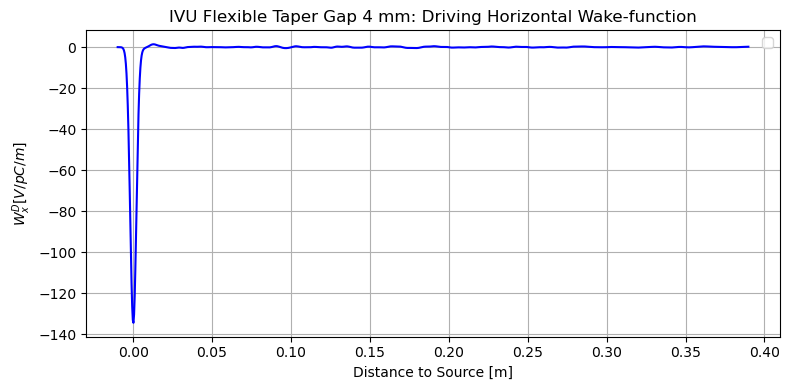

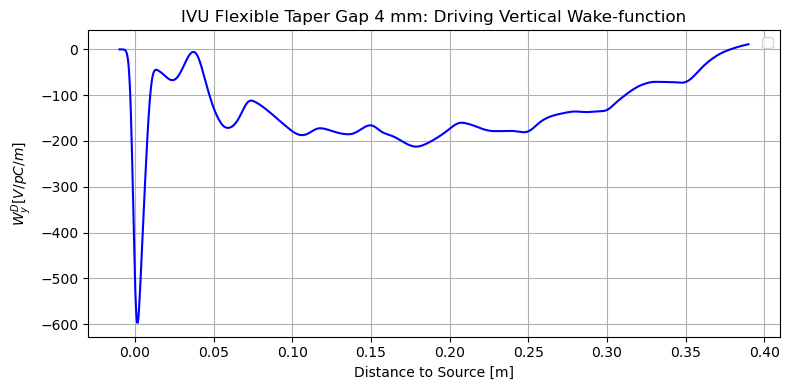

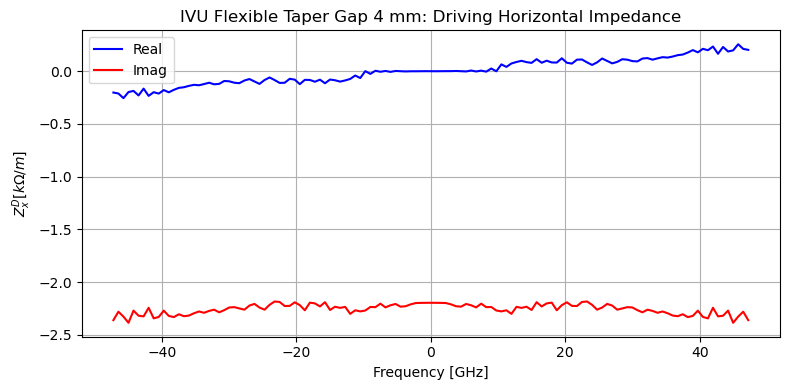

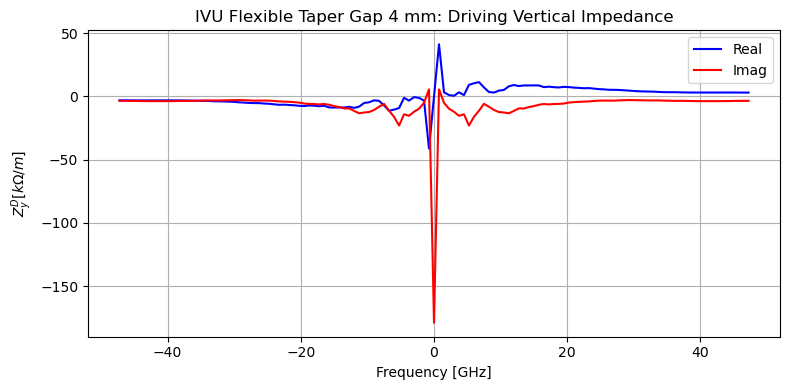

In [134]:
utils.plot_el(els[0], props=props, show=True)

#### 14 mm gap

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


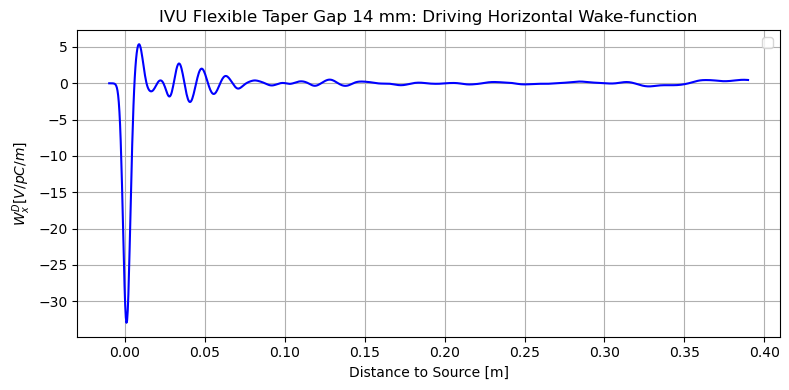

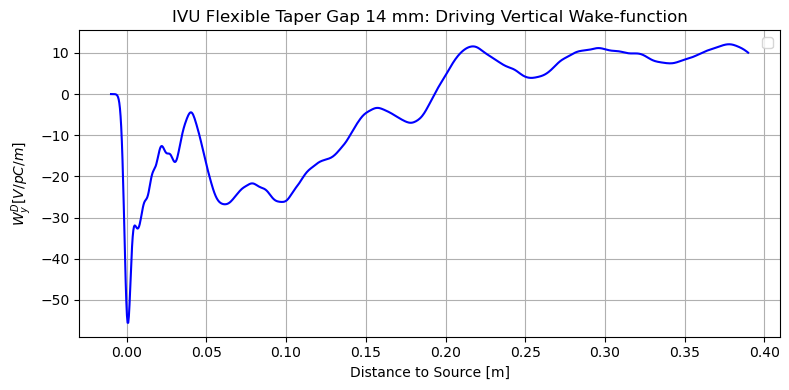

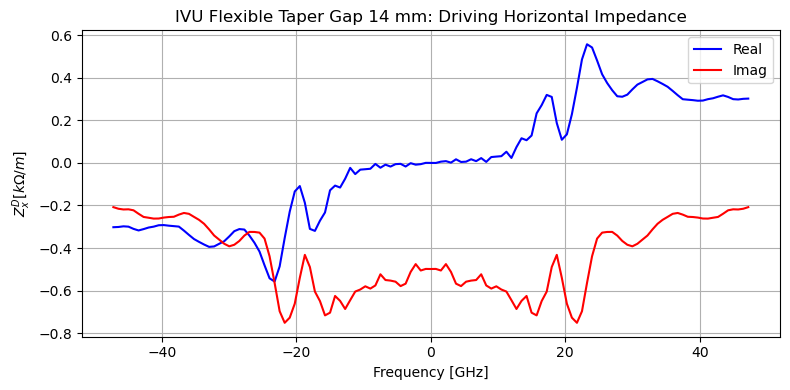

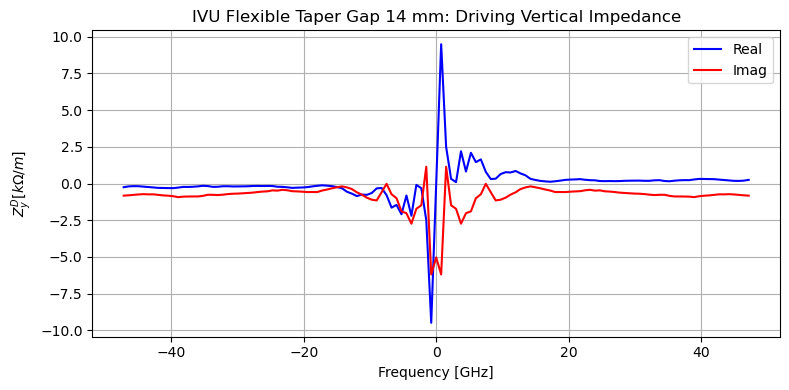

In [135]:
utils.plot_el(els[1], props=props, show=True)

#### 24 mm gap

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


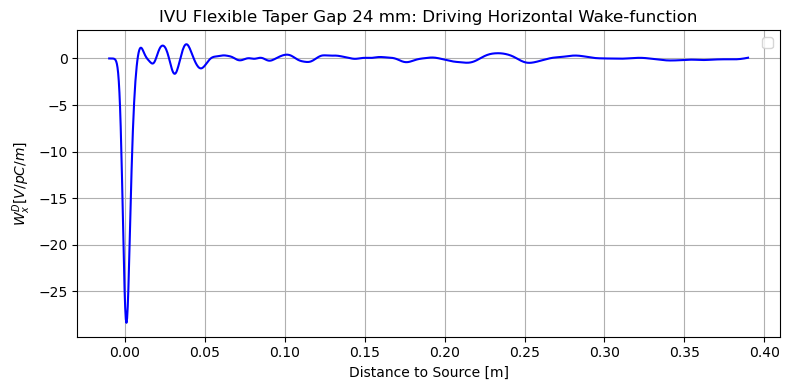

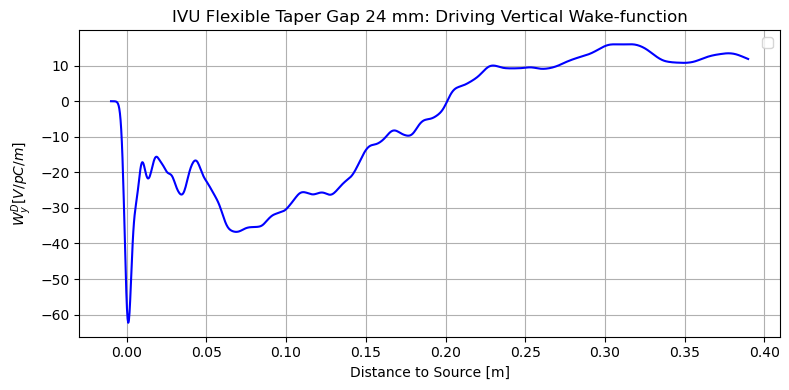

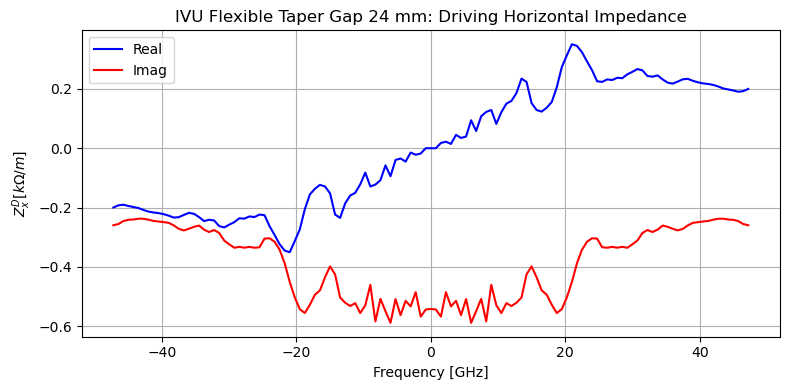

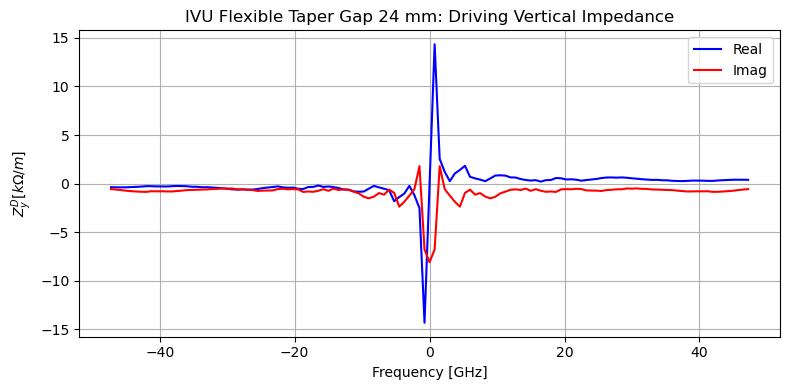

In [136]:
utils.plot_el(els[2], props=props, show=True)

#### Comparing Vertical Impedances @ Different Gaps

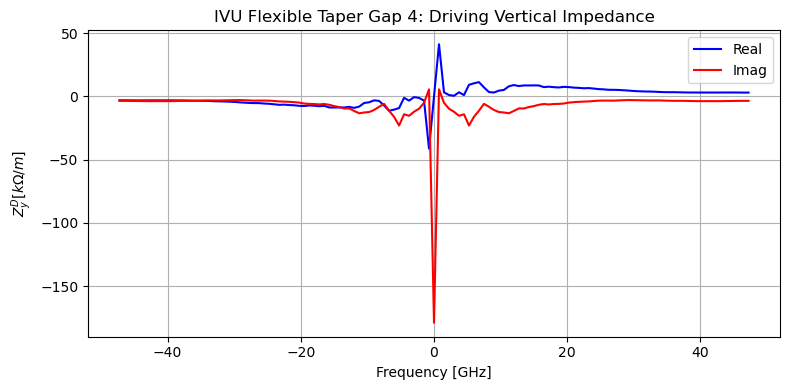

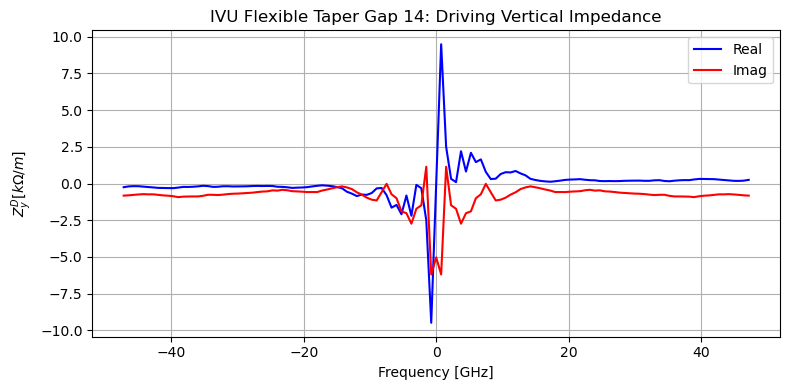

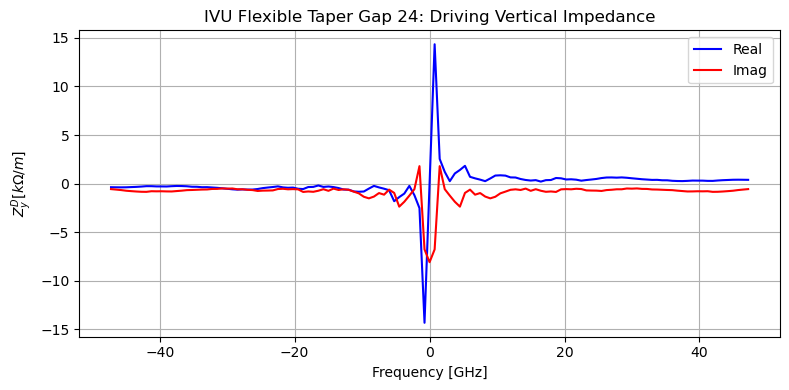

In [6]:
for el in els:
    utils.plot_el(el, props='Zdy', show=True)

### Save element

In [7]:
for el in els:
    el.save(overwrite=True)